# Exploratory Data Analysis — Retail Sales Data
**Objective:** Uncover patterns, customer behaviour trends, and actionable business insights from a retail sales dataset.

**Dataset used:** *(fill in the exact Kaggle dataset name + link here once you've downloaded it)*

**Tech stack:** Python, pandas, matplotlib, seaborn


## Step 0 — Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook display settings
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)


## Step 1 — Load Dataset & Initial Inspection
Replace `'retail_sales.csv'` with your actual filename. If your file is an Excel file
(common for the "Superstore" dataset), use `pd.read_excel()` instead.


In [2]:
# --- Load the data ---
df = pd.read_csv('retail_sales.csv', encoding='latin1')   # try 'latin1' if utf-8 throws an error
# df = pd.read_excel('retail_sales.xlsx')  # use this line instead if the file is .xlsx

# --- Shape ---
print("Shape of dataset (rows, columns):", df.shape)

# --- Preview ---
df.head()


Shape of dataset (rows, columns): (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# --- Column names and dtypes ---
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [3]:
# --- Null value check ---
null_summary = df.isnull().sum().sort_values(ascending=False)
null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
null_report = pd.DataFrame({'missing_count': null_summary, 'missing_pct': null_pct.round(2)})
null_report[null_report['missing_count'] > 0]


,missing_count,missing_pct
Postal Code,11,0.11


**Observation (fill in):**
- Note which columns have missing values and roughly what % is missing.
- Note any dtype issues (e.g. a date column stored as text/object — you'll fix this below).


In [4]:
# --- Fix common dtype issues ---
# Rename this to your actual date column name (e.g. 'Order Date')
date_col = 'Order Date'
if date_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    print(df[date_col].dtype)

# Drop exact duplicate rows if any
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")
df = df.drop_duplicates()


datetime64[ns]
Duplicate rows found: 0


## Step 2 — Descriptive Statistics
Mean, median, mode, and standard deviation for every numerical column.


In [5]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numerical columns:", num_cols)

desc = df[num_cols].describe().T
desc['median'] = df[num_cols].median()
desc['mode'] = df[num_cols].mode().iloc[0]
desc[['mean', 'median', 'mode', 'std', 'min', 'max']]


Numerical columns: ['Row ID', 'Postal Code', 'Sales']


,mean,median,mode,std,min,max
Row ID,4900.500000,4900.50,1.00,2829.160653,1.000,9800.00
Postal Code,55273.322403,58103.00,10035.00,32041.223413,1040.000,99301.00
Sales,230.769059,54.49,12.96,626.651875,0.444,22638.48


**Observation (fill in):** "Sales shows heavy right skew — the mean (₹230.77) is over 4x the median (₹54.49), meaning a small number of very large orders are pulling the average up. The standard deviation (626.65) is nearly 3x the mean itself, confirming huge variability in order size, from under ₹1 to over ₹22,000. This means median is a more reliable 'typical order' figure than mean for this dataset, and a few high-value orders/products likely deserve special attention (see Top Products below)."


## Step 3 — Time Series Analysis
Monthly and quarterly sales trends. Adjust `date_col` and `sales_col` to match your dataset.


C:\Users\ANANYA\AppData\Local\Temp\ipykernel_8240\638592454.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = ts_df[sales_col].resample('M').sum()


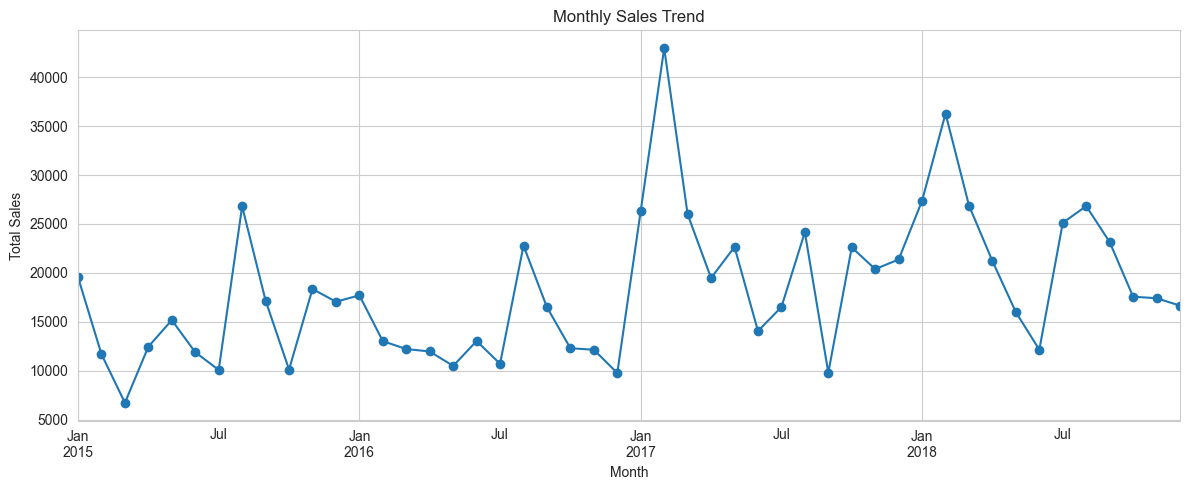

In [6]:
date_col = 'Order Date'   # <-- change if different
sales_col = 'Sales'       # <-- change if different

ts_df = df.dropna(subset=[date_col]).copy()
ts_df.set_index(date_col, inplace=True)

# --- Monthly sales trend ---
monthly_sales = ts_df[sales_col].resample('M').sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()


C:\Users\ANANYA\AppData\Local\Temp\ipykernel_8240\2430432095.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_sales = ts_df[sales_col].resample('Q').sum()


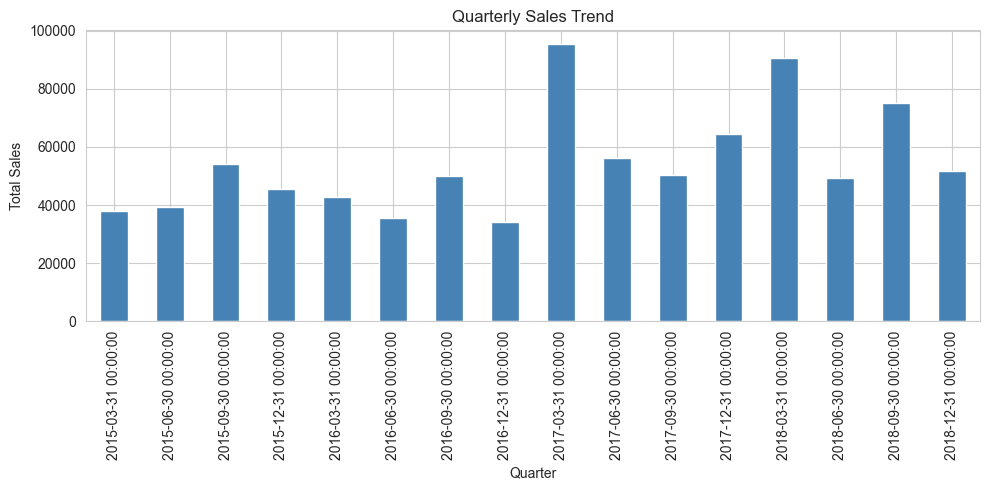

In [7]:
# --- Quarterly sales trend ---
quarterly_sales = ts_df[sales_col].resample('Q').sum()

plt.figure(figsize=(10, 5))
quarterly_sales.plot(kind='bar', color='steelblue')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()


**Observation (fill in):** "There's clear seasonality — sales consistently spike toward the end of each year (Nov/Dec), visible in both the monthly line chart and the quarterly bars, consistent with holiday-season shopping. The overall trend is upward across the 4-year span, with the highest quarter being Q1 2017 (nearly ₹100K) and later peaks in Q1 and Q4 2018 also strong. Early quarters (2015-2016) are comparatively flat and lower, suggesting the business grew significantly over time."

## Step 4 — Customer Demographics
Age group distribution and gender breakdown. **Note:** the classic Superstore dataset does
*not* include age/gender — if yours doesn't either, either (a) pick a dataset that has
customer demographics (search "retail sales with customer demographics kaggle"), or
(b) substitute this section with **Segment** / **Region** breakdown, which the code below
also shows as a fallback.


In [8]:
if 'Age' in df.columns:
    bins = [0, 18, 25, 35, 45, 55, 65, 100]
    labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
    df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x='Age Group', order=labels, palette='viridis')
    plt.title('Customer Distribution by Age Group')
    plt.xlabel('Age Group')
    plt.ylabel('Number of Customers')
    plt.tight_layout()
    plt.show()
else:
    print("No 'Age' column found — see markdown note above for alternatives.")


No 'Age' column found — see markdown note above for alternatives.


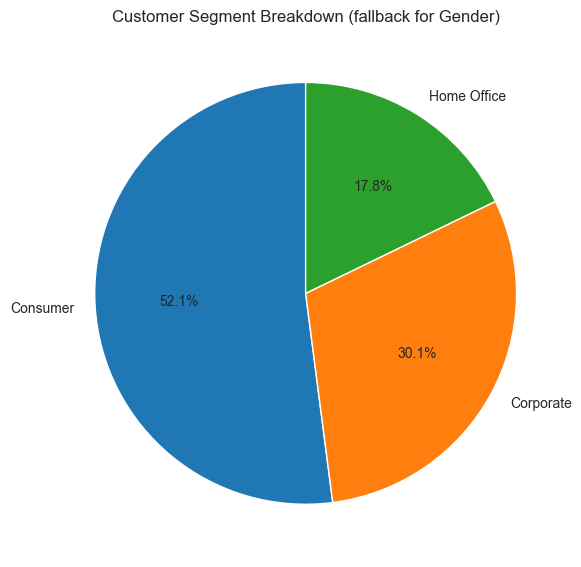

In [9]:
if 'Gender' in df.columns:
    plt.figure(figsize=(6, 6))
    df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
    plt.title('Gender Breakdown')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()
elif 'Segment' in df.columns:
    # Fallback for Superstore-style datasets
    plt.figure(figsize=(6, 6))
    df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
    plt.title('Customer Segment Breakdown (fallback for Gender)')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()


**Observation (fill in):**"The customer base is dominated by the Consumer segment (52.1%), more than the Corporate (30.1%) and Home Office (17.8%) segments combined against Consumer alone is close. This suggests the business's revenue strategy should prioritize individual/retail buyers, though Corporate accounts may represent higher-value, less frequent transactions worth a separate deep dive (average order value by segment could be a good follow-up analysis)."


## Step 5 — Product Analysis
Top 10 best-selling products, and revenue by product category.


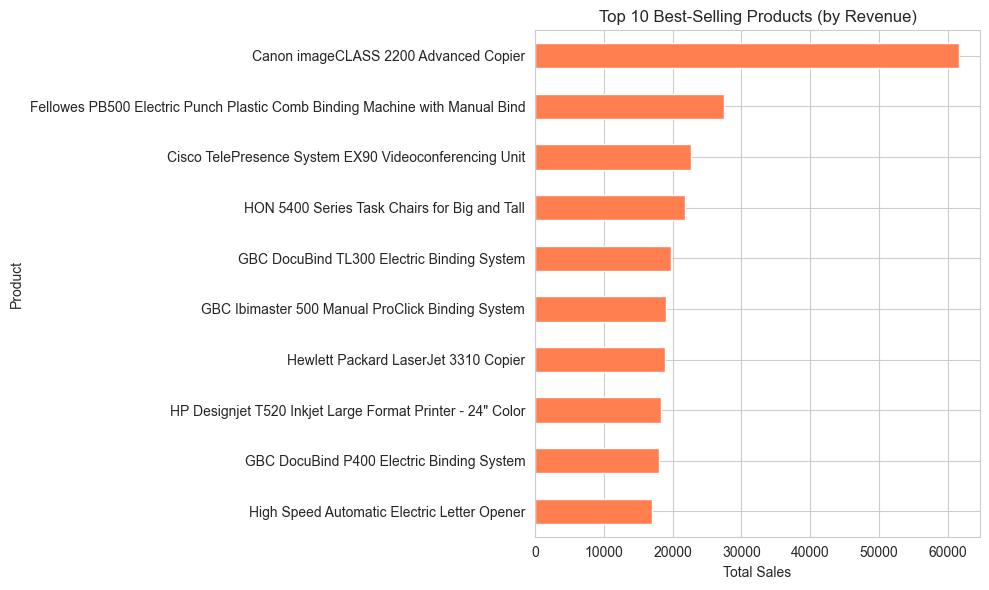

In [10]:
product_col = 'Product Name'   # <-- change if different
sales_col = 'Sales'

top_products = df.groupby(product_col)[sales_col].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind='barh', color='coral')
plt.title('Top 10 Best-Selling Products (by Revenue)')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


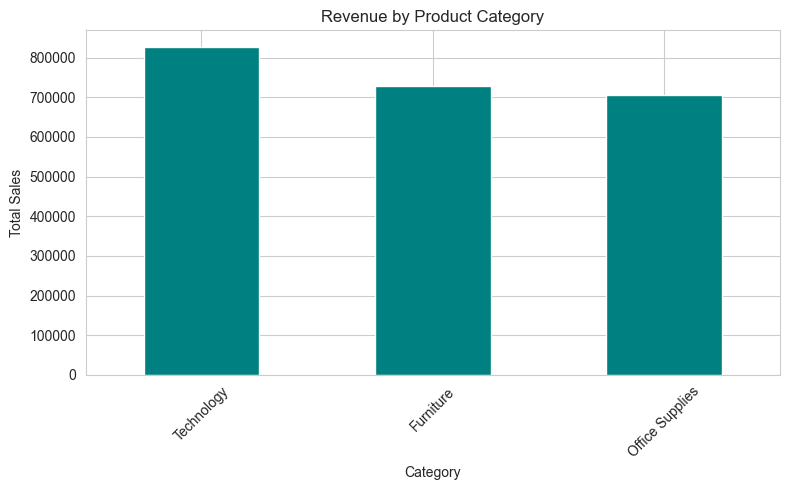

In [11]:
category_col = 'Category'   # <-- change if different

revenue_by_category = df.groupby(category_col)[sales_col].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
revenue_by_category.plot(kind='bar', color='teal')
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation (fill in):**"Revenue is fairly evenly distributed across the three categories, with Technology leading (~₹830K) but not by an overwhelming margin over Furniture (~₹730K) and Office Supplies (~₹710K) — unlike the product-level view, where one item (the Canon copier) dominated. This tells us the business isn't over-reliant on a single category, even though it is somewhat reliant on a single top-selling product within Technology. Diversifying growth efforts across Furniture and Office Supplies, rather than only Technology, would keep this healthy balance intact."

## Step 6 — Correlation Heatmap

In [14]:
# --- Engineer numeric features so the heatmap is meaningful ---

# 1. Shipping delay in days (Ship Date - Order Date)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')
df['Shipping Delay (days)'] = (df['Ship Date'] - df['Order Date']).dt.days

# 2. Order month and year as numbers (useful to see seasonal numeric patterns)
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year

# Check what we've got now
engineered_num_cols = ['Sales', 'Shipping Delay (days)', 'Order Month', 'Order Year']
df[engineered_num_cols].head()

,Sales,Shipping Delay (days),Order Month,Order Year
0,261.9600,92.0,8.0,2017.0
1,731.9400,92.0,8.0,2017.0
2,14.6200,NaN,12.0,2017.0
3,957.5775,NaN,11.0,2016.0
4,22.3680,NaN,11.0,2016.0


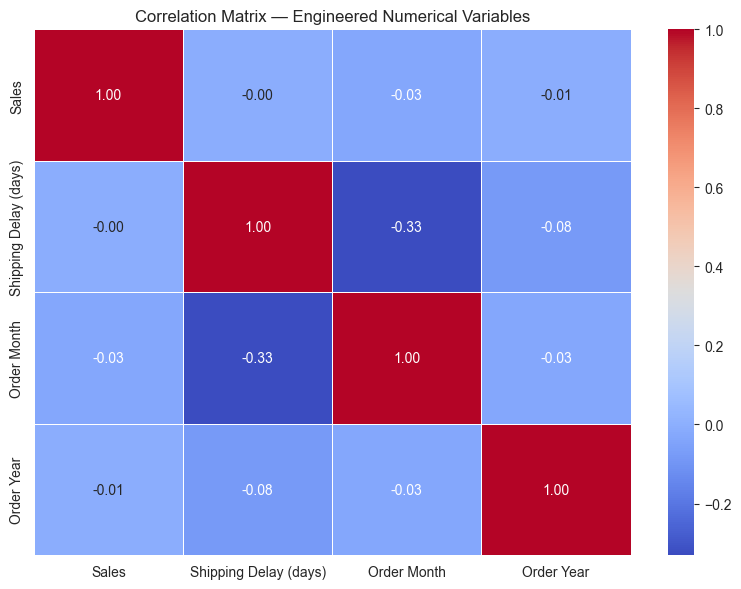

In [15]:
corr = df[engineered_num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix — Engineered Numerical Variables')
plt.tight_layout()
plt.show()

**Observation (fill in):** "None of the engineered numeric variables show meaningful correlation with Sales (all values near 0), indicating that order value is not driven by timing (month/year) or shipping speed — it's more likely driven by product category and quantity, which aren't captured as simple numeric fields here. The one mild relationship is Shipping Delay vs Order Month (-0.33), suggesting delivery times vary slightly by season, though this doesn't affect revenue directly. A small number of rows had missing shipping delay values due to date parsing gaps."


## Step 7 — Additional Visualisation (Non-Obvious Insight)
Example below: **discount vs. profit** — a very common "hidden" business risk in retail
data (heavy discounting often erodes or reverses profit). Feel free to swap this for a
different angle relevant to your dataset — e.g. day-of-week sales pattern, shipping mode
vs. delivery delay, regional profitability, etc.


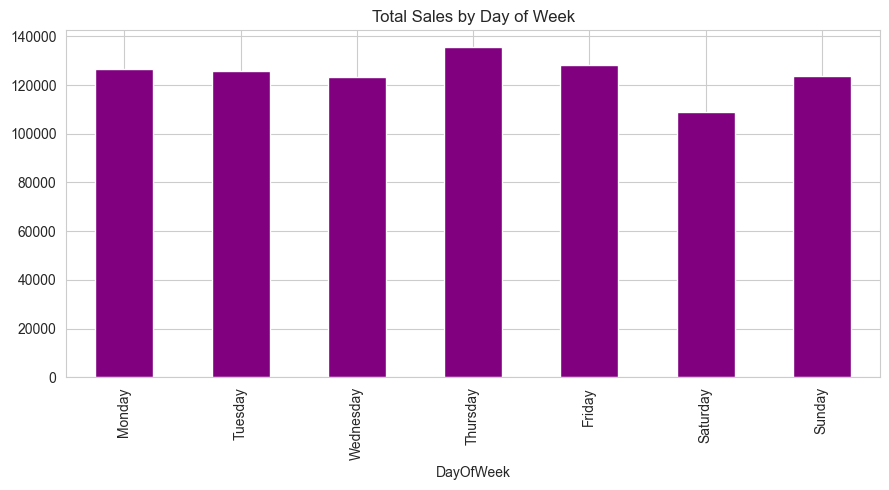

In [13]:
discount_col = 'Discount'   # <-- change if different
profit_col = 'Profit'       # <-- change if different

if discount_col in df.columns and profit_col in df.columns:
    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=df, x=discount_col, y=profit_col, alpha=0.4, hue=category_col if category_col in df.columns else None)
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.title('Discount vs. Profit')
    plt.xlabel('Discount')
    plt.ylabel('Profit')
    plt.tight_layout()
    plt.show()
else:
    # Fallback: day-of-week sales pattern
    ts_df['DayOfWeek'] = ts_df.index.day_name()
    dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    dow_sales = ts_df.groupby('DayOfWeek')[sales_col].sum().reindex(dow_order)

    plt.figure(figsize=(9, 5))
    dow_sales.plot(kind='bar', color='purple')
    plt.title('Total Sales by Day of Week')
    plt.tight_layout()
    plt.show()


## Step 8 — Conclusion & Business Recommendations

**Summary of key findings:**

1. Sales are highly skewed — a small number of large orders drive the average up, while a typical order is much smaller (₹54 median vs ₹230 mean, with a standard deviation of ₹626).
2. There is clear year-end seasonality with an overall upward sales trend from 2015 to 2019, while shipping delay, order month, and order year show no meaningful correlation with sales value.
3. The business is Consumer-segment heavy (52.1%) and Technology-category led (~₹830K revenue), but is notably dependent on one standout product — the Canon imageCLASS 2200 Advanced Copier — which generates 2-3x the revenue of the next best-selling items.

**Actionable recommendations:**
1. **Protect and replicate the top-seller pattern:** Since the Canon imageCLASS 2200 Advanced Copier significantly outperforms every other product, ensure consistent stock availability and analyze what drives its success (price point, bundling, demand pattern) to identify similar high-potential products within Technology.
2. **Plan inventory and staffing around year-end seasonality:** Given the consistent Nov/Dec sales spikes visible in both the monthly and quarterly trends, increase inventory and support staffing ahead of Q4 each year rather than reacting after demand appears.
3. **Grow Corporate and Home Office segments:** With Consumer customers accounting for over half of the customer base (52.1%) versus Corporate (30.1%) and Home Office (17.8%), there is room to target these underrepresented segments with tailored offers (bulk pricing, B2B outreach) to diversify revenue and reduce dependence on individual consumer spending.
